# 6 — Regression Modeling

Implements Stage 6 from `research_project_plan_v2.md` with a focus on predictive accuracy for binary team outcomes.

**Inputs:**
- `data/session_features.parquet` or CSV fallback
- optional `data/model_ready_features.parquet` or CSV fallback
- `data/chunk_registry_v1.csv` or `chunk_registry_v2.*`
- optional `data/validation/feature_inclusion_decision.csv`

**Outputs:**
- `results/loso_auc_summary.csv`
- `results/loco_auc_summary.csv`
- `results/univariate_screening_results.csv`
- `results/mixed_effects_results.csv`
- `results/beginning_segment_results.csv`
- `figures/roc_curves_primary_models.png`
- `figures/feature_importance_lasso.png`
- `figures/feature_importance_rf_permutation.png`
- `figures/beginning_vs_full_session_auc_comparison.png`


## Step 0 — Imports and paths

In [15]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from IPython.display import display
from scipy.stats import norm
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import ElasticNetCV, LogisticRegression, LogisticRegressionCV
from sklearn.metrics import (
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import LeaveOneOut
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

CANDIDATE_ROOTS = [
    Path.cwd(),
    Path.cwd() / 'analysis_v2',
    Path.cwd().parent,
]

ANALYSIS_V2 = next(
    (p for p in CANDIDATE_ROOTS if (p / 'data').exists() and (p / 'notebooks').exists()),
    None
)
if ANALYSIS_V2 is None:
    raise FileNotFoundError('Could not locate analysis_v2 directory from current working directory')

DATA_DIR = ANALYSIS_V2 / 'data'
RESULTS_DIR = ANALYSIS_V2 / 'results'
FIG_DIR = ANALYSIS_V2 / 'figures'
VALIDATION_DIR = DATA_DIR / 'validation'

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

print('ANALYSIS_V2 :', ANALYSIS_V2)
print('DATA_DIR    :', DATA_DIR)
print('RESULTS_DIR :', RESULTS_DIR)
print('FIG_DIR     :', FIG_DIR)


ANALYSIS_V2 : /Users/maxchalekson/Projects/NICO-Research/gemini_data_analysis/analysis_v2
DATA_DIR    : /Users/maxchalekson/Projects/NICO-Research/gemini_data_analysis/analysis_v2/data
RESULTS_DIR : /Users/maxchalekson/Projects/NICO-Research/gemini_data_analysis/analysis_v2/results
FIG_DIR     : /Users/maxchalekson/Projects/NICO-Research/gemini_data_analysis/analysis_v2/figures


## Step 1 — Load modeling tables

In [16]:
def load_table(stem: str) -> pd.DataFrame:
    parquet_path = DATA_DIR / f'{stem}.parquet'
    csv_path = DATA_DIR / f'{stem}.csv'

    if parquet_path.exists():
        try:
            return pd.read_parquet(parquet_path)
        except Exception as e:
            print(f'Falling back to CSV for {stem}: {type(e).__name__}: {e}')

    if csv_path.exists():
        return pd.read_csv(csv_path)

    raise FileNotFoundError(f'Could not find {parquet_path} or {csv_path}')


try:
    features_df = load_table('model_ready_features')
    feature_source = 'model_ready_features'
except FileNotFoundError:
    features_df = load_table('session_features')
    feature_source = 'session_features'

registry_name = (
    'chunk_registry_v2'
    if (DATA_DIR / 'chunk_registry_v2.csv').exists() or (DATA_DIR / 'chunk_registry_v2.parquet').exists()
    else 'chunk_registry_v1'
)
registry = load_table(registry_name)

session_meta = (
    registry.groupby('session_group', as_index=False)
    .agg(
        conference_id=('conference_id', 'first'),
        outcome_has_teams=('has_teams', 'max'),
        outcome_has_funded_teams=('has_funded_teams', 'max'),
        outcome_num_teams=('num_teams', 'max'),
        outcome_num_funded_teams=('num_funded_teams', 'max'),
        n_chunks=('chunk_id', 'count')
    )
)

# Only merge columns that are missing from features_df
cols_to_add = ['session_group'] + [
    c for c in session_meta.columns
    if c != 'session_group' and c not in features_df.columns
]

model_df = features_df.merge(
    session_meta[cols_to_add],
    on='session_group',
    how='left'
)

print('Feature source:', feature_source)
print(f'Model df: {model_df.shape[0]:,} rows x {model_df.shape[1]} cols')

show_cols = [
    c for c in [
        'session_group',
        'conference_id',
        'outcome_has_teams',
        'outcome_has_funded_teams',
        'outcome_num_teams',
        'outcome_num_funded_teams'
    ]
    if c in model_df.columns
]
display(model_df[show_cols].head())


Feature source: model_ready_features
Model df: 162 rows x 361 cols


,session_group,conference_id,outcome_has_teams,outcome_has_funded_teams,outcome_num_teams,outcome_num_funded_teams
0,2020_11_05_NES_S1,2020NES,1.0,0.0,1.0,0.0
1,2020_11_05_NES_S2,2020NES,1.0,0.0,3.0,0.0
2,2020_11_05_NES_S3,2020NES,1.0,1.0,3.0,1.0
3,2020_11_05_NES_S4,2020NES,1.0,1.0,1.0,1.0
4,2020_11_05_NES_S5,2020NES,1.0,1.0,1.0,1.0


## Step 2 — Feature selection and helper functions

In [17]:
OUTCOME_COLS = {
    'outcome_has_teams',
    'outcome_has_funded_teams',
    'outcome_num_teams',
    'outcome_num_funded_teams',
}
NON_FEATURE_COLS = {
    'session_group',
    'conference_id',
    'n_chunks',
} | OUTCOME_COLS

candidate_features = [
    c for c in model_df.columns
    if c not in NON_FEATURE_COLS and pd.api.types.is_numeric_dtype(model_df[c])
]

if not feature_decisions.empty:
    excluded = set(feature_decisions.loc[feature_decisions['decision'] == 'exclude', 'field'])
    candidate_features = [c for c in candidate_features if c not in excluded]

beginning_features = [c for c in candidate_features if c.startswith('session_beginning_')]
control_features = ['n_chunks'] if 'n_chunks' in model_df.columns else []

print(f'Candidate modeling features: {len(candidate_features)}')
print(f'Beginning-only features: {len(beginning_features)}')


def make_logistic_pipeline():
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', LogisticRegressionCV(
            Cs=np.logspace(-4, 4, 20),
            cv=5,
            penalty='elasticnet',
            solver='saga',
            l1_ratios=[0.1, 0.5, 0.9],
            scoring='roc_auc',
            random_state=RANDOM_STATE,
            max_iter=5000,
        ))
    ])


def make_simple_logistic_pipeline():
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(C=1.0, max_iter=5000, random_state=RANDOM_STATE))
    ])


def make_rf_pipeline():
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', RandomForestClassifier(n_estimators=500, max_features='sqrt', random_state=RANDOM_STATE))
    ])


def bootstrap_auc_ci(y_true, y_score, n_boot=1000, random_state=42):
    rng = np.random.default_rng(random_state)
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    aucs = []
    for _ in range(n_boot):
        idx = rng.integers(0, len(y_true), len(y_true))
        if len(np.unique(y_true[idx])) < 2:
            continue
        aucs.append(roc_auc_score(y_true[idx], y_score[idx]))
    if not aucs:
        return (np.nan, np.nan)
    return tuple(np.quantile(aucs, [0.025, 0.975]))


def evaluate_binary_cv(df, features, outcome, cv_groups=None, mode='loso', pipeline_factory=make_logistic_pipeline):
    work = df[['session_group', 'conference_id', outcome] + features].copy()
    work = work.dropna(subset=[outcome])
    X = work[features]
    y = work[outcome].astype(int)
    if len(np.unique(y)) < 2:
        raise ValueError(f'{outcome} has fewer than 2 classes after filtering')

    preds = pd.Series(index=work.index, dtype=float)
    if mode == 'loso':
        splitter = LeaveOneOut().split(X)
    elif mode == 'loco':
        groups = work['conference_id']
        unique_groups = groups.dropna().unique()
        splitter = []
        for g in unique_groups:
            test_idx = np.where(groups.values == g)[0]
            train_idx = np.where(groups.values != g)[0]
            if len(test_idx) and len(train_idx):
                splitter.append((train_idx, test_idx))
    else:
        raise ValueError('mode must be loso or loco')

    for train_idx, test_idx in tqdm(list(splitter), desc=f'{mode.upper()} {outcome}', unit='fold'):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train = y.iloc[train_idx]
        if len(np.unique(y_train)) < 2:
            continue
        pipe = pipeline_factory()
        pipe.fit(X_train, y_train)
        preds.iloc[test_idx] = pipe.predict_proba(X_test)[:, 1]

    valid = preds.notna()
    y_valid = y.loc[valid]
    p_valid = preds.loc[valid]
    pred_labels = (p_valid >= 0.5).astype(int)
    auc_val = roc_auc_score(y_valid, p_valid) if len(np.unique(y_valid)) == 2 else np.nan
    ci_low, ci_high = bootstrap_auc_ci(y_valid, p_valid)
    return {
        'n': len(y_valid),
        'auc': auc_val,
        'auc_ci_low': ci_low,
        'auc_ci_high': ci_high,
        'balanced_accuracy': balanced_accuracy_score(y_valid, pred_labels),
        'f1': f1_score(y_valid, pred_labels, zero_division=0),
        'confusion_matrix': confusion_matrix(y_valid, pred_labels).tolist(),
        'y_true': y_valid.reset_index(drop=True),
        'y_score': p_valid.reset_index(drop=True),
    }


def evaluate_count_loso(df, features, outcome):
    work = df[[outcome] + features].copy().dropna(subset=[outcome])
    X = work[features]
    y = pd.to_numeric(work[outcome], errors='coerce')
    preds = pd.Series(index=work.index, dtype=float)
    splitter = LeaveOneOut().split(X)
    for train_idx, test_idx in tqdm(list(splitter), desc=f'LOSO {outcome}', unit='fold'):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train = y.iloc[train_idx]
        pipe = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('model', ElasticNetCV(l1_ratio=[0.1, 0.5, 0.9], random_state=RANDOM_STATE))
        ])
        pipe.fit(X_train, y_train)
        preds.iloc[test_idx] = pipe.predict(X_test)
    valid = preds.notna()
    y_valid = y.loc[valid]
    p_valid = preds.loc[valid]
    return {
        'n': len(y_valid),
        'rmse': np.sqrt(mean_squared_error(y_valid, p_valid)),
        'mae': mean_absolute_error(y_valid, p_valid),
        'r2': r2_score(y_valid, p_valid),
    }


Candidate modeling features: 354
Beginning-only features: 64


## Step 3 — Primary model: regularized logistic regression

In [18]:
binary_outcomes = ['outcome_has_teams', 'outcome_has_funded_teams']
primary_rows = []
primary_curves = {}

for outcome in binary_outcomes:
    result = evaluate_binary_cv(model_df, candidate_features, outcome, mode='loso', pipeline_factory=make_logistic_pipeline)
    primary_rows.append({
        'model': 'logistic_elasticnet',
        'outcome': outcome,
        'cv': 'LOSO',
        'n': result['n'],
        'auc': result['auc'],
        'auc_ci_low': result['auc_ci_low'],
        'auc_ci_high': result['auc_ci_high'],
        'balanced_accuracy': result['balanced_accuracy'],
        'f1': result['f1'],
        'confusion_matrix': str(result['confusion_matrix']),
    })
    primary_curves[outcome] = result

loso_summary = pd.DataFrame(primary_rows)
loso_path = RESULTS_DIR / 'loso_auc_summary.csv'
loso_summary.to_csv(loso_path, index=False)
print('Saved:', loso_path)
display(loso_summary)


LOSO outcome_has_teams:   0%|          | 0/156 [00:00<?, ?fold/s]

LOSO outcome_has_funded_teams:   0%|          | 0/156 [00:00<?, ?fold/s]

Saved: /Users/maxchalekson/Projects/NICO-Research/gemini_data_analysis/analysis_v2/results/loso_auc_summary.csv


,model,outcome,cv,n,auc,auc_ci_low,auc_ci_high,balanced_accuracy,f1,confusion_matrix
0,logistic_elasticnet,outcome_has_teams,LOSO,156,0.431880,0.332799,0.538835,0.500000,0.881720,"[[0, 33], [0, 123]]"
1,logistic_elasticnet,outcome_has_funded_teams,LOSO,156,0.617981,0.520378,0.708437,0.598262,0.534351,"[[60, 28], [33, 35]]"


## Step 4 — LOCO robustness check

In [19]:
loco_rows = []
for outcome in binary_outcomes:
    result = evaluate_binary_cv(model_df, candidate_features, outcome, mode='loco', pipeline_factory=make_logistic_pipeline)
    loco_rows.append({
        'model': 'logistic_elasticnet',
        'outcome': outcome,
        'cv': 'LOCO',
        'n': result['n'],
        'auc': result['auc'],
        'auc_ci_low': result['auc_ci_low'],
        'auc_ci_high': result['auc_ci_high'],
        'balanced_accuracy': result['balanced_accuracy'],
        'f1': result['f1'],
        'confusion_matrix': str(result['confusion_matrix']),
    })

loco_summary = pd.DataFrame(loco_rows)
loco_path = RESULTS_DIR / 'loco_auc_summary.csv'
loco_summary.to_csv(loco_path, index=False)
print('Saved:', loco_path)
display(loco_summary)


LOCO outcome_has_teams:   0%|          | 0/8 [00:00<?, ?fold/s]

LOCO outcome_has_funded_teams:   0%|          | 0/8 [00:00<?, ?fold/s]

Saved: /Users/maxchalekson/Projects/NICO-Research/gemini_data_analysis/analysis_v2/results/loco_auc_summary.csv


,model,outcome,cv,n,auc,auc_ci_low,auc_ci_high,balanced_accuracy,f1,confusion_matrix
0,logistic_elasticnet,outcome_has_teams,LOCO,156,0.371890,0.270808,0.479183,0.495935,0.877698,"[[0, 33], [1, 122]]"
1,logistic_elasticnet,outcome_has_funded_teams,LOCO,156,0.484459,0.396532,0.575159,0.465909,0.300885,"[[60, 28], [51, 17]]"


## Step 5 — Single-feature logistic screening

In [20]:
def benjamini_hochberg(pvals: pd.Series) -> pd.Series:
    pvals = pvals.fillna(1.0)
    n = len(pvals)
    ranks = pvals.rank(method='first')
    qvals = pvals * n / ranks
    return qvals.clip(upper=1.0)


screen_rows = []
target_outcome = 'outcome_has_funded_teams'
screen_features = candidate_features[: min(len(candidate_features), 75)]

for feature in tqdm(screen_features, desc='Univariate screening', unit='feature'):
    try:
        result = evaluate_binary_cv(model_df, [feature] + control_features, target_outcome, mode='loso', pipeline_factory=make_simple_logistic_pipeline)
        auc_val = result['auc']
        z = 0 if np.isnan(auc_val) else (auc_val - 0.5) / max(1e-6, np.sqrt(1 / max(result['n'], 1)))
        pval = 2 * (1 - norm.cdf(abs(z))) if not np.isnan(auc_val) else np.nan
        screen_rows.append({'feature': feature, 'outcome': target_outcome, 'auc_loso': auc_val, 'n': result['n'], 'approx_p_value': pval})
    except Exception as e:
        screen_rows.append({'feature': feature, 'outcome': target_outcome, 'auc_loso': np.nan, 'n': 0, 'approx_p_value': np.nan, 'error': str(e)[:120]})

screen_df = pd.DataFrame(screen_rows)
screen_df['bh_q_value'] = benjamini_hochberg(screen_df['approx_p_value'])
screen_path = RESULTS_DIR / 'univariate_screening_results.csv'
screen_df.to_csv(screen_path, index=False)
print('Saved:', screen_path)
display(screen_df.sort_values('auc_loso', ascending=False).head(20))


Univariate screening:   0%|          | 0/75 [00:00<?, ?feature/s]

LOSO outcome_has_funded_teams:   0%|          | 0/156 [00:00<?, ?fold/s]

LOSO outcome_has_funded_teams:   0%|          | 0/156 [00:00<?, ?fold/s]

LOSO outcome_has_funded_teams:   0%|          | 0/156 [00:00<?, ?fold/s]

LOSO outcome_has_funded_teams:   0%|          | 0/156 [00:00<?, ?fold/s]

...

LOSO outcome_has_funded_teams:   0%|          | 0/156 [00:00<?, ?fold/s]

LOSO outcome_has_funded_teams:   0%|          | 0/156 [00:00<?, ?fold/s]

LOSO outcome_has_funded_teams:   0%|          | 0/156 [00:00<?, ?fold/s]

Saved: /Users/maxchalekson/Projects/NICO-Research/gemini_data_analysis/analysis_v2/results/univariate_screening_results.csv


,feature,outcome,auc_loso,n,approx_p_value,bh_q_value
61,session_middle_num_Evaluation_Practices,outcome_has_funded_teams,0.635695,156,0.090107,1.0
59,session_mean_num_Evaluation_Practices,outcome_has_funded_teams,0.626504,156,0.114099,1.0
14,session_mean_dissent_was_present,outcome_has_funded_teams,0.609459,156,0.171582,1.0
19,session_mean_dissent_response_exploratory,outcome_has_funded_teams,0.604947,156,0.189932,1.0
68,session_delta_num_Relational_Climate,outcome_has_funded_teams,0.586731,156,0.278687,1.0
56,session_middle_num_Knowledge_Sharing,outcome_has_funded_teams,0.582386,156,0.303477,1.0
54,session_mean_num_Knowledge_Sharing,outcome_has_funded_teams,0.582219,156,0.304459,1.0
67,session_end_num_Relational_Climate,outcome_has_funded_teams,0.574532,156,0.351902,1.0
16,session_middle_dissent_was_present,outcome_has_funded_teams,0.574198,156,0.354066,1.0
39,session_mean_meeting_structure_quality,outcome_has_funded_teams,0.569686,156,0.384095,1.0


## Step 6 — Random forest robustness check

In [21]:
rf_rows = []
rf_curves = {}

for outcome in binary_outcomes:
    result = evaluate_binary_cv(model_df, candidate_features, outcome, mode='loso', pipeline_factory=make_rf_pipeline)
    rf_rows.append({
        'model': 'random_forest',
        'outcome': outcome,
        'cv': 'LOSO',
        'n': result['n'],
        'auc': result['auc'],
        'auc_ci_low': result['auc_ci_low'],
        'auc_ci_high': result['auc_ci_high'],
        'balanced_accuracy': result['balanced_accuracy'],
        'f1': result['f1'],
        'confusion_matrix': str(result['confusion_matrix']),
    })
    rf_curves[outcome] = result

rf_summary = pd.DataFrame(rf_rows)
rf_summary


LOSO outcome_has_teams:   0%|          | 0/156 [00:00<?, ?fold/s]

LOSO outcome_has_funded_teams:   0%|          | 0/156 [00:00<?, ?fold/s]

,model,outcome,cv,n,auc,auc_ci_low,auc_ci_high,balanced_accuracy,f1,confusion_matrix
0,random_forest,outcome_has_teams,LOSO,156,0.629096,0.517387,0.733479,0.533259,0.879121,"[[3, 30], [3, 120]]"
1,random_forest,outcome_has_funded_teams,LOSO,156,0.534425,0.442179,0.626460,0.527072,0.396552,"[[63, 25], [45, 23]]"


## Step 7 — Conference-clustered logistic model proxy

In [22]:
# The project plan requests a conference-clustered model. For a binary outcome,
# use a fixed-effects logistic regression proxy with conference indicators.
top_features = screen_df.sort_values('auc_loso', ascending=False)['feature'].dropna().tolist()[:10]
formula_terms = top_features + ['C(conference_id)']
formula = 'outcome_has_funded_teams ~ ' + ' + '.join(formula_terms)

mixed_results_rows = []
try:
    mixed_df = model_df[['outcome_has_funded_teams', 'conference_id'] + top_features].dropna(subset=['outcome_has_funded_teams'])
    mixed_model = sm.Logit.from_formula(formula, data=mixed_df)
    mixed_result = mixed_model.fit(disp=False)
    mixed_results_rows = pd.DataFrame({
        'term': mixed_result.params.index,
        'coef': mixed_result.params.values,
        'se': mixed_result.bse.values,
        'z': mixed_result.tvalues.values,
        'p_value': mixed_result.pvalues.values,
    })
except Exception as e:
    mixed_results_rows = pd.DataFrame([{'term': 'MODEL_FAILED', 'coef': np.nan, 'se': np.nan, 'z': np.nan, 'p_value': np.nan, 'error': str(e)}])

mixed_path = RESULTS_DIR / 'mixed_effects_results.csv'
mixed_results_rows.to_csv(mixed_path, index=False)
print('Saved:', mixed_path)
display(mixed_results_rows.head(20))


Saved: /Users/maxchalekson/Projects/NICO-Research/gemini_data_analysis/analysis_v2/results/mixed_effects_results.csv


,term,coef,se,z,p_value
0,Intercept,-0.996575,1.751231,-0.569071,0.569308
1,C(conference_id)[T.2021ABI],-1.041898,0.906952,-1.148790,0.250642
2,C(conference_id)[T.2021CMC],-0.337748,0.936813,-0.360529,0.718452
3,C(conference_id)[T.2021MND],-1.628170,0.941891,-1.728619,0.083877
4,C(conference_id)[T.2021MZT],-0.023985,0.932510,-0.025721,0.979480
5,C(conference_id)[T.2021NES],-0.162373,0.916734,-0.177121,0.859414
6,C(conference_id)[T.2021SLU],-0.017488,0.880821,-0.019855,0.984159
7,C(conference_id)[T.2022MND],-0.251041,1.016235,-0.247031,0.804885
8,session_middle_num_Evaluation_Practices,-0.432214,0.400247,-1.079868,0.280201
9,session_mean_num_Evaluation_Practices,0.288611,0.556668,0.518462,0.604136


## Step 8 — Beginning-segment models

In [23]:
beginning_rows = []
if beginning_features:
    for outcome in binary_outcomes:
        result = evaluate_binary_cv(model_df, beginning_features, outcome, mode='loso', pipeline_factory=make_logistic_pipeline)
        beginning_rows.append({
            'model': 'beginning_logistic_elasticnet',
            'outcome': outcome,
            'cv': 'LOSO',
            'n': result['n'],
            'auc': result['auc'],
            'auc_ci_low': result['auc_ci_low'],
            'auc_ci_high': result['auc_ci_high'],
            'balanced_accuracy': result['balanced_accuracy'],
            'f1': result['f1'],
        })
else:
    print('No beginning-only features found.')

beginning_df = pd.DataFrame(beginning_rows)
beginning_path = RESULTS_DIR / 'beginning_segment_results.csv'
beginning_df.to_csv(beginning_path, index=False)
print('Saved:', beginning_path)
display(beginning_df)


LOSO outcome_has_teams:   0%|          | 0/156 [00:00<?, ?fold/s]

LOSO outcome_has_funded_teams:   0%|          | 0/156 [00:00<?, ?fold/s]

Saved: /Users/maxchalekson/Projects/NICO-Research/gemini_data_analysis/analysis_v2/results/beginning_segment_results.csv


,model,outcome,cv,n,auc,auc_ci_low,auc_ci_high,balanced_accuracy,f1
0,beginning_logistic_elasticnet,outcome_has_teams,LOSO,156,0.423503,0.324940,0.526486,0.500000,0.881720
1,beginning_logistic_elasticnet,outcome_has_funded_teams,LOSO,156,0.351604,0.260074,0.438051,0.395053,0.210526


## Step 9 — Secondary count-outcome models

In [24]:
count_rows = []
for outcome in ['outcome_num_teams', 'outcome_num_funded_teams']:
    result = evaluate_count_loso(model_df, candidate_features, outcome)
    count_rows.append({'model': 'elasticnet_regression', 'outcome': outcome, **result})

count_df = pd.DataFrame(count_rows)
count_path = RESULTS_DIR / 'count_outcome_summary.csv'
count_df.to_csv(count_path, index=False)
print('Saved:', count_path)
display(count_df)


LOSO outcome_num_teams:   0%|          | 0/156 [00:00<?, ?fold/s]

LOSO outcome_num_funded_teams:   0%|          | 0/156 [00:00<?, ?fold/s]

Saved: /Users/maxchalekson/Projects/NICO-Research/gemini_data_analysis/analysis_v2/results/count_outcome_summary.csv


,model,outcome,n,rmse,mae,r2
0,elasticnet_regression,outcome_num_teams,156,1.179729,0.952646,-0.029011
1,elasticnet_regression,outcome_num_funded_teams,156,0.728655,0.607804,-0.024576


## Step 10 — Figures

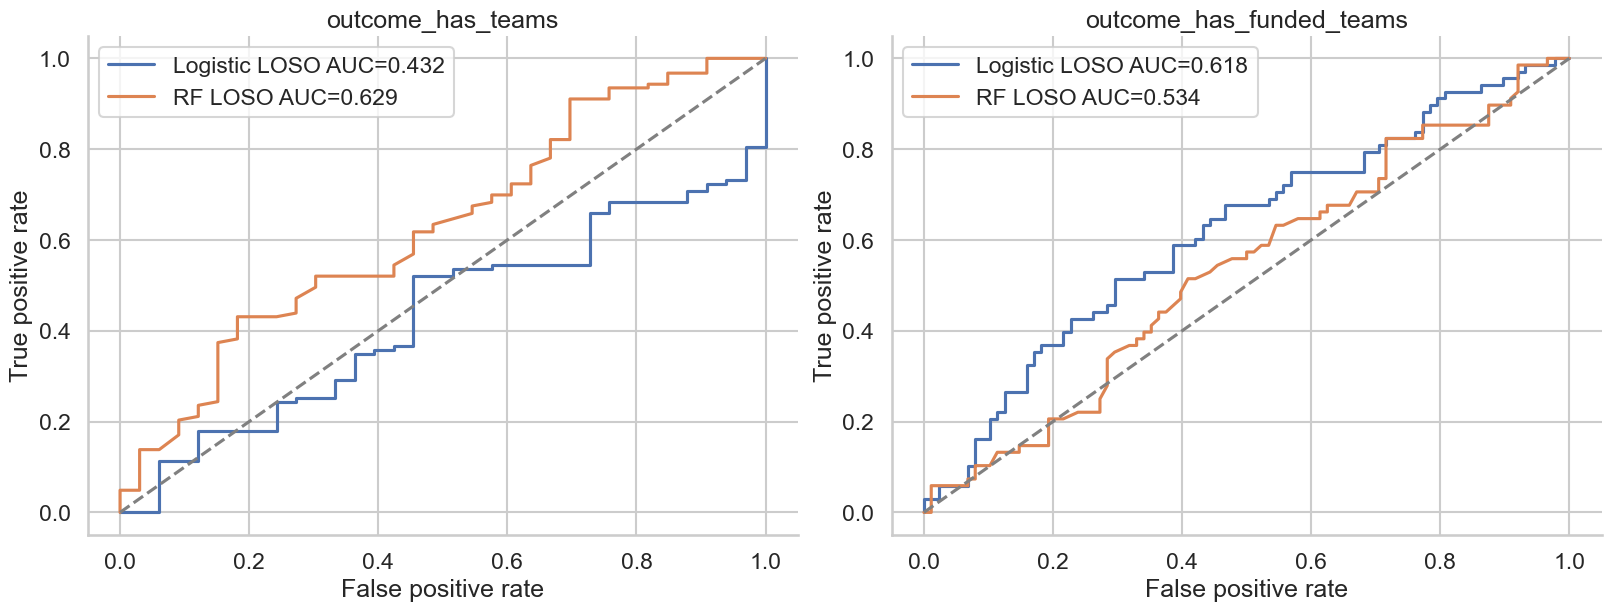

Saved: /Users/maxchalekson/Projects/NICO-Research/gemini_data_analysis/analysis_v2/figures/roc_curves_primary_models.png


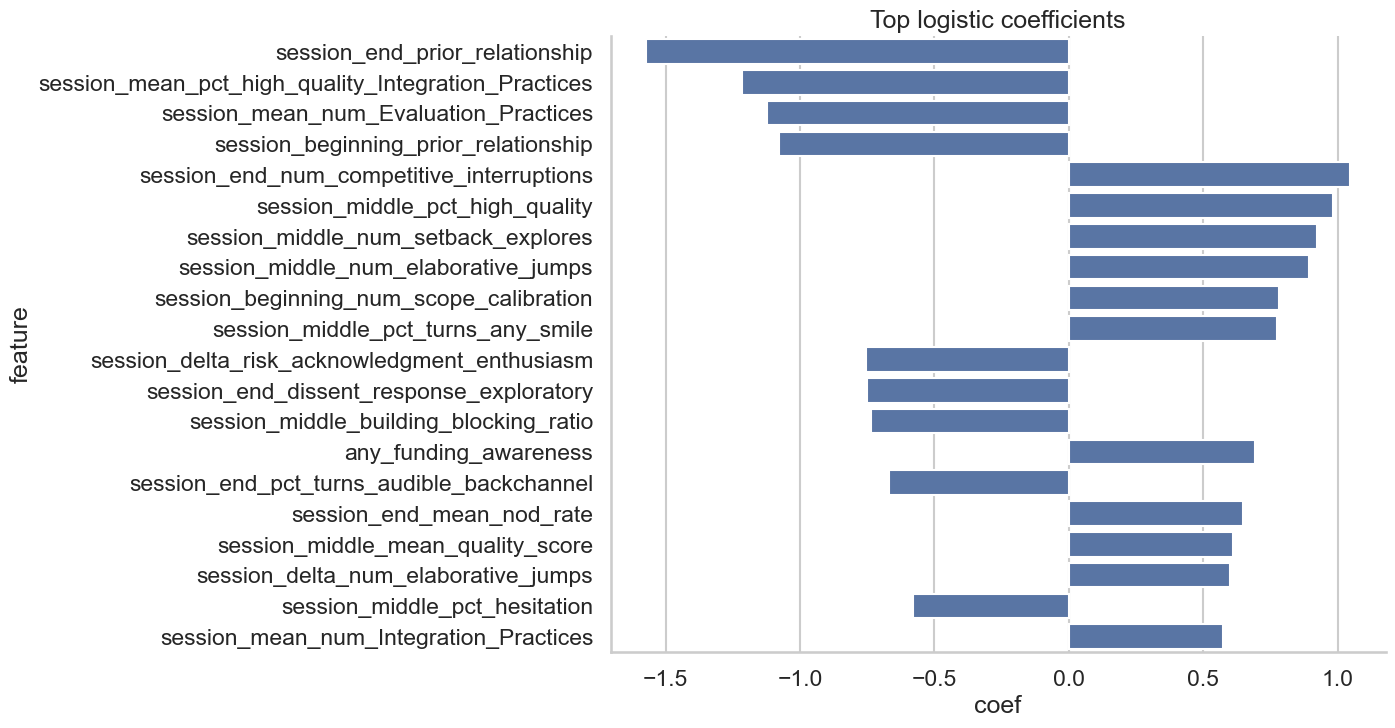

Saved: /Users/maxchalekson/Projects/NICO-Research/gemini_data_analysis/analysis_v2/figures/feature_importance_lasso.png


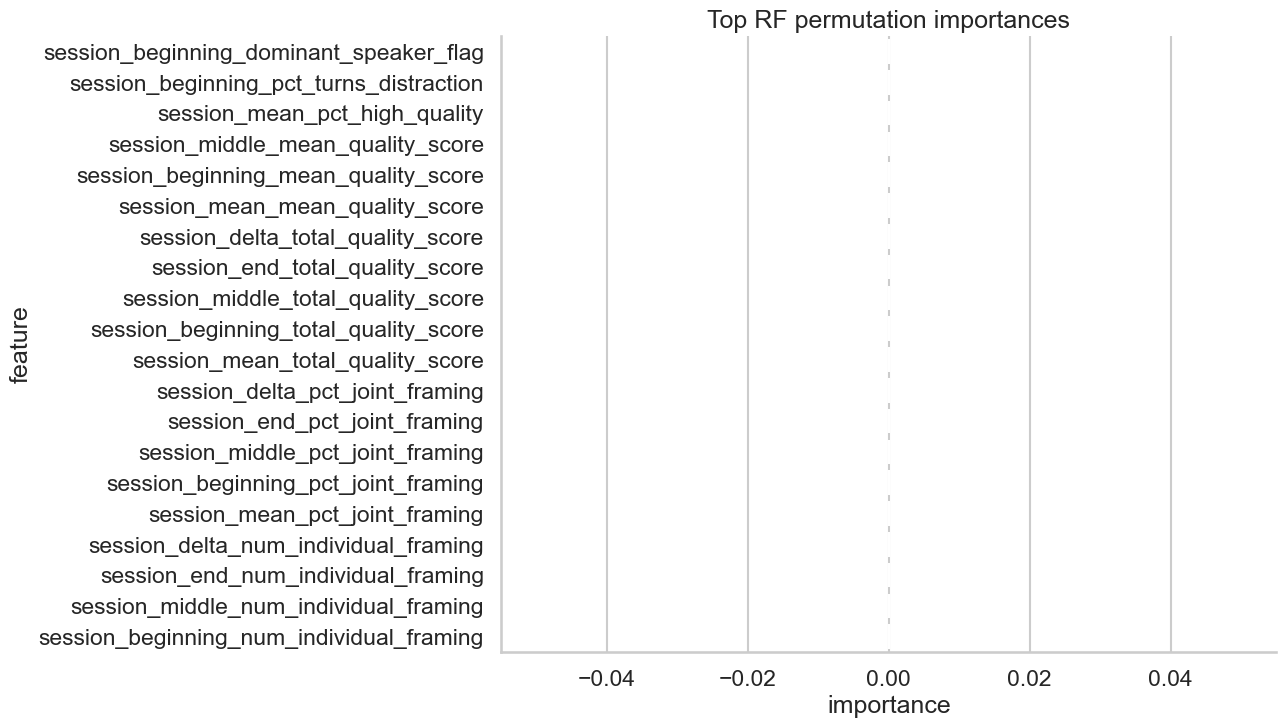

Saved: /Users/maxchalekson/Projects/NICO-Research/gemini_data_analysis/analysis_v2/figures/feature_importance_rf_permutation.png


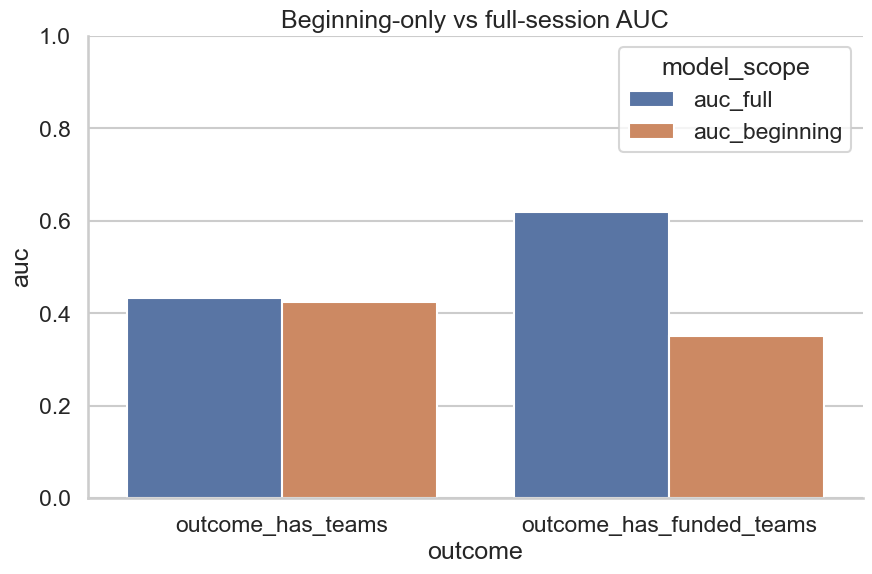

Saved: /Users/maxchalekson/Projects/NICO-Research/gemini_data_analysis/analysis_v2/figures/beginning_vs_full_session_auc_comparison.png


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)
for ax, outcome in zip(axes, binary_outcomes):
    if outcome in primary_curves:
        y_true = primary_curves[outcome]['y_true']
        y_score = primary_curves[outcome]['y_score']
        fpr, tpr, _ = roc_curve(y_true, y_score)
        ax.plot(fpr, tpr, label=f'Logistic LOSO AUC={primary_curves[outcome]["auc"]:.3f}')
    if outcome in rf_curves:
        y_true = rf_curves[outcome]['y_true']
        y_score = rf_curves[outcome]['y_score']
        fpr, tpr, _ = roc_curve(y_true, y_score)
        ax.plot(fpr, tpr, label=f'RF LOSO AUC={rf_curves[outcome]["auc"]:.3f}')
    ax.plot([0, 1], [0, 1], linestyle='--', color='gray')
    ax.set_title(outcome)
    ax.set_xlabel('False positive rate')
    ax.set_ylabel('True positive rate')
    ax.legend()

roc_path = FIG_DIR / 'roc_curves_primary_models.png'
fig.savefig(roc_path, dpi=200, bbox_inches='tight')
plt.show()
print('Saved:', roc_path)

final_pipe = make_logistic_pipeline()
target_outcome = 'outcome_has_funded_teams'
fit_df = model_df[candidate_features + [target_outcome]].dropna(subset=[target_outcome])
final_pipe.fit(fit_df[candidate_features], fit_df[target_outcome].astype(int))
coef = final_pipe.named_steps['model'].coef_.ravel()
coef_df = pd.DataFrame({'feature': candidate_features, 'coef': coef}).sort_values('coef', key=np.abs, ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(data=coef_df, y='feature', x='coef', ax=ax, color='#4c72b0')
ax.set_title('Top logistic coefficients')
lasso_fig_path = FIG_DIR / 'feature_importance_lasso.png'
fig.savefig(lasso_fig_path, dpi=200, bbox_inches='tight')
plt.show()
print('Saved:', lasso_fig_path)

rf_pipe = make_rf_pipeline()
rf_pipe.fit(fit_df[candidate_features], fit_df[target_outcome].astype(int))
perm = permutation_importance(rf_pipe, fit_df[candidate_features], fit_df[target_outcome].astype(int), n_repeats=20, random_state=RANDOM_STATE)
perm_df = pd.DataFrame({'feature': candidate_features, 'importance': perm.importances_mean}).sort_values('importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(data=perm_df, y='feature', x='importance', ax=ax, color='#dd8452')
ax.set_title('Top RF permutation importances')
rf_fig_path = FIG_DIR / 'feature_importance_rf_permutation.png'
fig.savefig(rf_fig_path, dpi=200, bbox_inches='tight')
plt.show()
print('Saved:', rf_fig_path)

compare_df = loso_summary[['outcome', 'auc']].merge(beginning_df[['outcome', 'auc']], on='outcome', how='left', suffixes=('_full', '_beginning'))
plot_df = compare_df.melt(id_vars='outcome', value_vars=['auc_full', 'auc_beginning'], var_name='model_scope', value_name='auc')
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=plot_df, x='outcome', y='auc', hue='model_scope', ax=ax)
ax.set_ylim(0, 1)
ax.set_title('Beginning-only vs full-session AUC')
begin_fig_path = FIG_DIR / 'beginning_vs_full_session_auc_comparison.png'
fig.savefig(begin_fig_path, dpi=200, bbox_inches='tight')
plt.show()
print('Saved:', begin_fig_path)
